# Классификация с помощью дерева решений (Census Income / Adult)

Лабораторная работа №3 по дисциплине **«Основы интеллектуального анализа данных»**.

**Задание:** разработать программу, которая выполняет классификацию набора данных с помощью дерева решений. Параметры программы:

1. набор данных (Census Income / Adult: годовой доход — `<=50K` или `>50K`);
2. критерий выбора атрибута разбиения: **Information gain**, **Gain ratio**, **Gini index**;
3. доля, которую занимает обучающая выборка от общего размера набора данных.

**План экспериментов:**

- **Часть А:** обучение на 100% обучающих данных (`adult.data.txt`) тремя критериями, оценка на тестовой выборке (`adult.test.txt`), визуализация построенных деревьев;
- **Часть Б:** фиксируем критерий (Information gain) и варьируем соотношение мощностей обучающей и тестовой выборок от 60:40 до 90:10 с шагом 10%, считаем accuracy, precision, recall и F-меру, строим графики зависимости метрик от доли обучающей выборки.

Дерево решений написано **с нуля** на Python + NumPy, так же как Apriori в работах №1–2, без готовых классификаторов. Внутри три критерия: прирост информации по энтропии Шеннона (подход ID3), Gain ratio с нормировкой на Split info (подход C4.5) и прирост индекса Джини (подход CART).


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

TRAIN_PATH = "adult.data.txt"
TEST_PATH = "adult.test.txt"
RANDOM_STATE = 42

COLUMNS = ["age", "workclass", "fnlwgt", "education", "education-num",
           "marital-status", "occupation", "relationship", "race", "sex",
           "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]
NUM_FEATURES = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
CAT_FEATURES = ["workclass", "education", "marital-status", "occupation",
                "relationship", "race", "sex", "native-country"]
TARGET = "income"
POSITIVE = ">50K"

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.6 | numpy 2.5.3


## 1. Загрузка данных

Файлы набора Census Income (см. `adult.names.txt`):

- `adult.data.txt` — обучающая выборка, 32561 строка, без заголовка;
- `adult.test.txt` — тестовая выборка, 16281 строка; первая строка файла — комментарий `|1x3 Cross validator`, в конце каждой метки класса стоит точка (`<=50K.`).

Значения в строках разделены запятыми с пробелом (`skipinitialspace=True`), пропуски закодированы символом `?` (встречаются в `workclass`, `occupation`, `native-country`). Целевой признак — `income`: `<=50K` или `>50K`.

In [2]:
def load_adult(path, is_test=False):
    df = pd.read_csv(path, header=None, names=COLUMNS, skipinitialspace=True,
                     skiprows=1 if is_test else 0)
    if is_test:
        df[TARGET] = df[TARGET].str.rstrip(".")
    return df


train_df = load_adult(TRAIN_PATH)
test_df = load_adult(TEST_PATH, is_test=True)
print("Обучающий файл:", train_df.shape, "| тестовый файл:", test_df.shape)
print("Классы в train:", dict(train_df[TARGET].value_counts()))
print("Классы в test: ", dict(test_df[TARGET].value_counts()))
print("Строк с \"?\" в train:", int((train_df == "?").any(axis=1).sum()),
      "| в test:", int((test_df == "?").any(axis=1).sum()))
print("Доля класса >50K в train: %.3f" % (train_df[TARGET] == POSITIVE).mean())

Обучающий файл: (32561, 15) | тестовый файл: (16281, 15)
Классы в train: {'<=50K': np.int64(24720), '>50K': np.int64(7841)}
Классы в test:  {'<=50K': np.int64(12435), '>50K': np.int64(3846)}
Строк с "?" в train: 2399 | в test: 1221
Доля класса >50K в train: 0.241


## 2. Предобработка

1. Удаляем строки с неизвестными значениями `?` — так же сделано в эталонных экспериментах из `adult.names.txt` (там указано: без unknowns train=30162, test=15060).
2. Целевой признак кодируем бинарно: `>50K` → 1 (положительный класс), `<=50K` → 0.
3. Категориальные признаки раскрываем one-hot кодированием, числовые оставляем как есть. Столбцы тестовой матрицы выравниваем под обучающую (редкие страны могут не пересекаться).

In [3]:
def prepare(df, columns=None):
    df = df[~(df == "?").any(axis=1)].copy()
    y = (df[TARGET] == POSITIVE).to_numpy(dtype=np.int64)
    X = pd.get_dummies(df[NUM_FEATURES + CAT_FEATURES], columns=CAT_FEATURES, dtype=np.float64)
    if columns is not None:
        X = X.reindex(columns=columns, fill_value=0)
    return X.to_numpy(dtype=np.float64), y, list(X.columns)


X_full, y_full, feature_names = prepare(train_df)
X_test, y_test, _ = prepare(test_df, columns=feature_names)
print("Очищенный train:", X_full.shape, "| очищенный test:", X_test.shape)
print("Признаков после one-hot:", len(feature_names))
print("Доля >50K: train=%.4f test=%.4f" % (y_full.mean(), y_test.mean()))
print("Пример one-hot признаков:", feature_names[6:11])

Очищенный train: (30162, 104) | очищенный test: (15060, 104)
Признаков после one-hot: 104
Доля >50K: train=0.2489 test=0.2457
Пример one-hot признаков: ['workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc']


## 3. Дерево решений: реализация с нуля

Строим бинарное дерево жадным рекурсивным разбиением. В каждом узле перебираем все признаки с порогами-кандидатами: у бинарных порог один, посередине отрезка, у числовых берём квантили. Лучшим считается разбиение с наибольшим значением заданного критерия:

- **Information gain** (ID3): `IG = H(parent) − wL·H(L) − wR·H(R)`, где `H` — энтропия Шеннона;
- **Gain ratio** (C4.5): `GR = IG / SplitInfo`, `SplitInfo = −wL·log2(wL) − wR·log2(wR)`. Прирост делится на Split info, так штрафуются разбиения на много мелких ветвей;
- **Gini index** (CART): прирост `G(parent) − wL·G(L) − wR·G(R)`, `G = 1 − Σ p²`.

Ветвление останавливается, когда достигнута `max_depth`, когда объектов мало (`min_samples_split`), когда прирост меньше `min_gain` или когда узел чистый. Лист предсказывает мажоритарный класс. Метрики для положительного класса `>50K` (accuracy, precision, recall, F-мера) считаем по TP/FP/FN/TN вручную.


In [4]:
# Узел дерева: признак и порог разбиения, потомки, статистика узла.
class TreeNode:
    __slots__ = ("feature", "threshold", "left", "right", "proba", "n", "gain")

    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.proba = 0.0
        self.n = 0
        self.gain = 0.0


def _entropy(c0, c1):
    n = c0 + c1
    if n == 0:
        return 0.0
    h = 0.0
    for c in (c0, c1):
        if c > 0:
            p = c / n
            h -= p * np.log2(p)
    return h


def _gini(c0, c1):
    n = c0 + c1
    if n == 0:
        return 0.0
    p0, p1 = c0 / n, c1 / n
    return 1.0 - p0 * p0 - p1 * p1


class DecisionTree:
    def __init__(self, criterion="information_gain", max_depth=8,
                 min_samples_split=50, min_gain=1e-4, n_thresholds=12):
        assert criterion in ("information_gain", "gain_ratio", "gini")
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_gain = min_gain
        self.n_thresholds = n_thresholds
        self.root = None
        self.feature_names = None

    def _impurity(self, c0, c1):
        if self.criterion in ("information_gain", "gain_ratio"):
            return _entropy(c0, c1)
        return _gini(c0, c1)

    def _best_split(self, X, y):
        n, m = X.shape
        c1 = float(y.sum())
        c0 = float(n - y.sum())
        parent = self._impurity(c0, c1)
        best = None
        for j in range(m):
            col = X[:, j]
            lo, hi = col.min(), col.max()
            if lo == hi:
                continue
            if len(np.unique(col)) == 2:
                thresholds = ((lo + hi) / 2.0,)
            else:
                qs = np.linspace(0, 1, self.n_thresholds + 2)[1:-1]
                thresholds = tuple(np.unique(np.quantile(col, qs)))
            for t in thresholds:
                left = col <= t
                nl = int(left.sum())
                nr = n - nl
                if nl < 2 or nr < 2:
                    continue
                l1 = float(y[left].sum())
                r1 = c1 - l1
                gain = parent - (nl / n) * self._impurity(nl - l1, l1) \
                     - (nr / n) * self._impurity(nr - r1, r1)
                if self.criterion == "gain_ratio":
                    wl, wr = nl / n, nr / n
                    split_info = -(wl * np.log2(wl) + wr * np.log2(wr))
                    if split_info < 1e-12:
                        continue
                    score = gain / split_info
                else:
                    score = gain
                if best is None or score > best[0]:
                    best = (score, gain, j, float(t))
        return best

    def _build(self, X, y, depth):
        node = TreeNode()
        node.n = X.shape[0]
        node.proba = float(y.mean()) if len(y) else 0.0
        if depth >= self.max_depth or len(y) < self.min_samples_split \
                or node.proba in (0.0, 1.0):
            return node
        best = self._best_split(X, y)
        if best is None or best[1] < self.min_gain:
            return node
        _, gain, j, t = best
        left = X[:, j] <= t
        if left.sum() == 0 or left.sum() == len(y):
            return node
        node.feature = j
        node.threshold = t
        node.gain = gain
        node.left = self._build(X[left], y[left], depth + 1)
        node.right = self._build(X[~left], y[~left], depth + 1)
        return node

    def fit(self, X, y, feature_names=None):
        self.feature_names = feature_names
        self.root = self._build(np.asarray(X, dtype=np.float64),
                                np.asarray(y, dtype=np.int64), 0)
        return self

    def _predict_one(self, x):
        node = self.root
        while node.feature is not None:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return 1 if node.proba >= 0.5 else 0

    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        return np.array([self._predict_one(row) for row in X], dtype=np.int64)

    def count_nodes(self):
        total, depth = 0, 0
        stack = [(self.root, 0)]
        while stack:
            node, d = stack.pop()
            total += 1
            depth = max(depth, d)
            if node.feature is not None:
                stack.append((node.left, d + 1))
                stack.append((node.right, d + 1))
        return total, depth


def classification_metrics(y_true, y_pred):
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


print("Реализация готова: DecisionTree(criterion=information_gain|gain_ratio|gini)")

Реализация готова: DecisionTree(criterion=information_gain|gain_ratio|gini)


## 4. Эксперимент А: обучение на 100% данных тремя критериями

Обучаем три дерева (`max_depth=8`, `min_samples_split=50`) на всех 30162 очищенных строках `adult.data.txt` и оцениваем на независимой тестовой выборке `adult.test.txt` (15060 строк). Положительный класс — `>50K`. Замеряем время обучения, число узлов и четыре метрики качества.

In [5]:
CRITERIA = ["information_gain", "gain_ratio", "gini"]
DEEP_DEPTH = 8
deep_trees = {}
rows_a = []
for criterion in CRITERIA:
    t0 = time.time()
    tree = DecisionTree(criterion=criterion, max_depth=DEEP_DEPTH).fit(X_full, y_full, feature_names)
    elapsed = time.time() - t0
    pred = tree.predict(X_test)
    m = classification_metrics(y_test, pred)
    nodes, depth = tree.count_nodes()
    deep_trees[criterion] = tree
    rows_a.append({"criterion": criterion, "time_s": round(elapsed, 1), "nodes": nodes,
                   "accuracy": round(m["accuracy"], 4), "precision": round(m["precision"], 4),
                   "recall": round(m["recall"], 4), "f1": round(m["f1"], 4)})
    print("%-16s time=%5.1f c  nodes=%3d  acc=%.4f prec=%.4f rec=%.4f f1=%.4f"
          % (criterion, elapsed, nodes, m["accuracy"], m["precision"], m["recall"], m["f1"]))
results_a = pd.DataFrame(rows_a)
print()
print(results_a.to_string(index=False))

information_gain time=  4.3 c  nodes=231  acc=0.8501 prec=0.7069 rec=0.6657 f1=0.6857
gain_ratio       time=  3.7 c  nodes= 89  acc=0.8376 prec=0.7340 rec=0.5316 f1=0.6166
gini             time=  3.9 c  nodes=227  acc=0.8502 prec=0.7120 rec=0.6554 f1=0.6825

       criterion  time_s  nodes  accuracy  precision  recall     f1
information_gain     4.3    231    0.8501     0.7069  0.6657 0.6857
      gain_ratio     3.7     89    0.8376     0.7340  0.5316 0.6166
            gini     3.9    227    0.8502     0.7120  0.6554 0.6825


## 5. Визуализация построенных деревьев

Полные деревья глубины 8 содержат до 231 узла, целиком такое не разглядеть. Поэтому для рисунков обучили тем же алгоритмом деревья с `max_depth=4` (до 31 узла): верхние уровни у них такие же, зато читается каждый узел. Левая ветвь означает, что условие выполнилось (`≤`), правая — что нет. В узле подписаны условие, число объектов и доля класса `>50K`.

Файлы рисунков: `tree_information_gain.png`, `tree_gain_ratio.png`, `tree_gini.png`.


information_gain shallow nodes=31 depth=4
gain_ratio       shallow nodes=27 depth=4
gini             shallow nodes=31 depth=4

Дерево information_gain (глубина 4), текстовый вид:
[marital-status_Married-civ-spouse <= 0.5] (gain=0.1529) [n=30162, p(>50K)=0.249]
  [education-num <= 12] (gain=0.0400) [n=16097, p(>50K)=0.069]
    [capital-gain <= 0] (gain=0.0173) [n=12694, p(>50K)=0.034]
      [age <= 27] (gain=0.0113) [n=12185, p(>50K)=0.026]
        => <=50K [n=4996, p(>50K)=0.005]
        => <=50K [n=7189, p(>50K)=0.041]
      [capital-gain <= 6.85e+03] (gain=0.5332) [n=509, p(>50K)=0.234]
        => <=50K [n=394, p(>50K)=0.033]
        => >50K [n=115, p(>50K)=0.922]
    [capital-gain <= 3.32e+03] (gain=0.0981) [n=3403, p(>50K)=0.198]
      [age <= 28] (gain=0.0509) [n=3151, p(>50K)=0.150]
        => <=50K [n=1067, p(>50K)=0.031]
        => <=50K [n=2084, p(>50K)=0.211]
      [capital-gain <= 7.43e+03] (gain=0.4379) [n=252, p(>50K)=0.794]
        => <=50K [n=80, p(>50K)=0.350]
        =

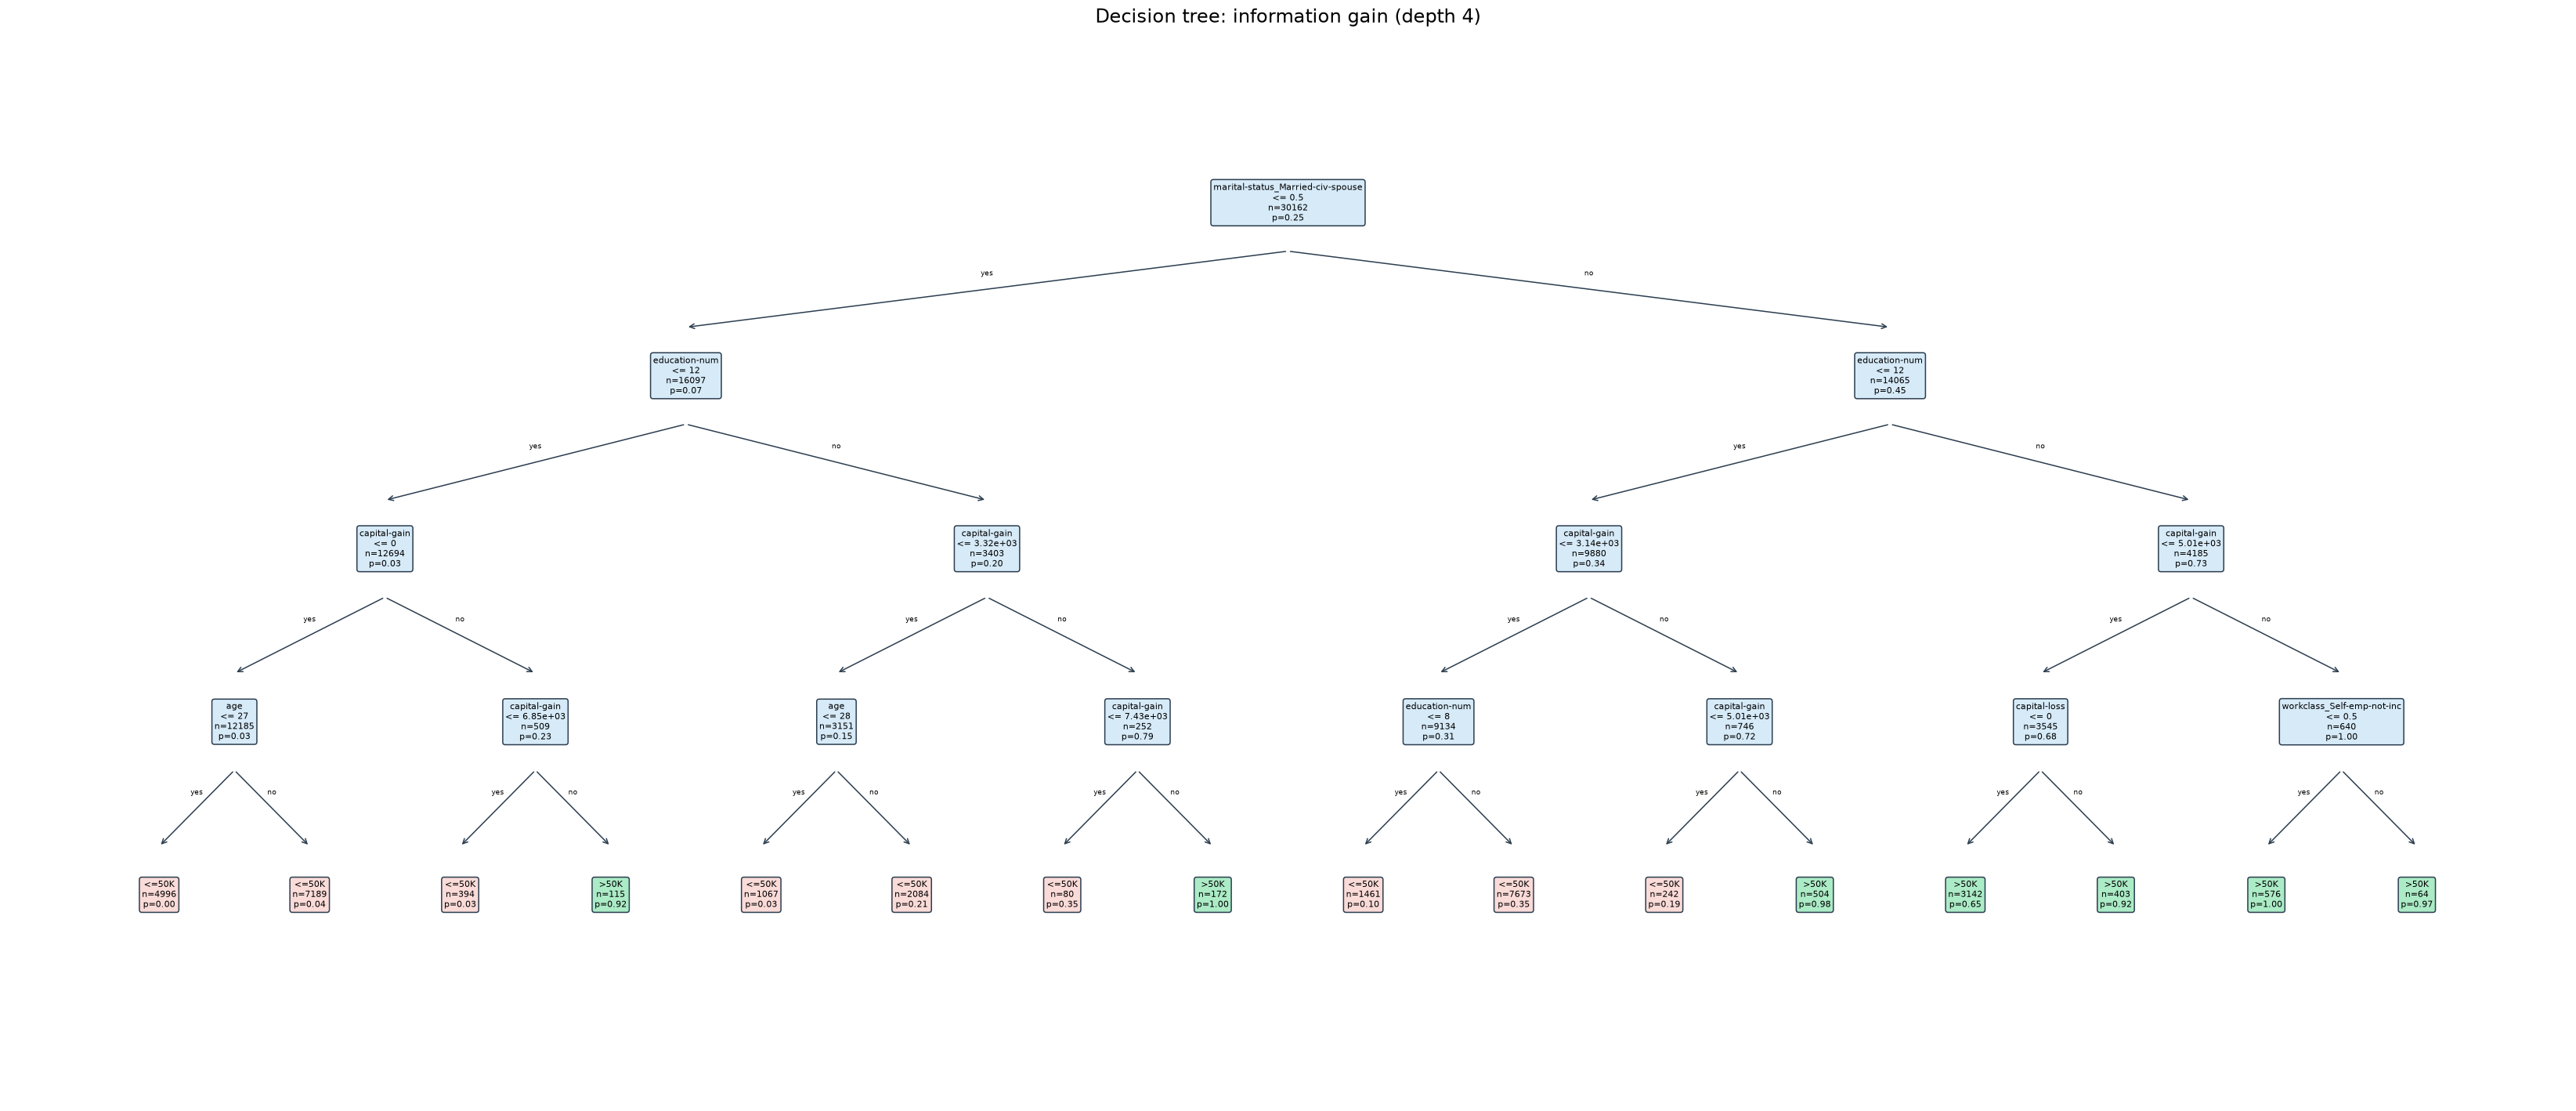

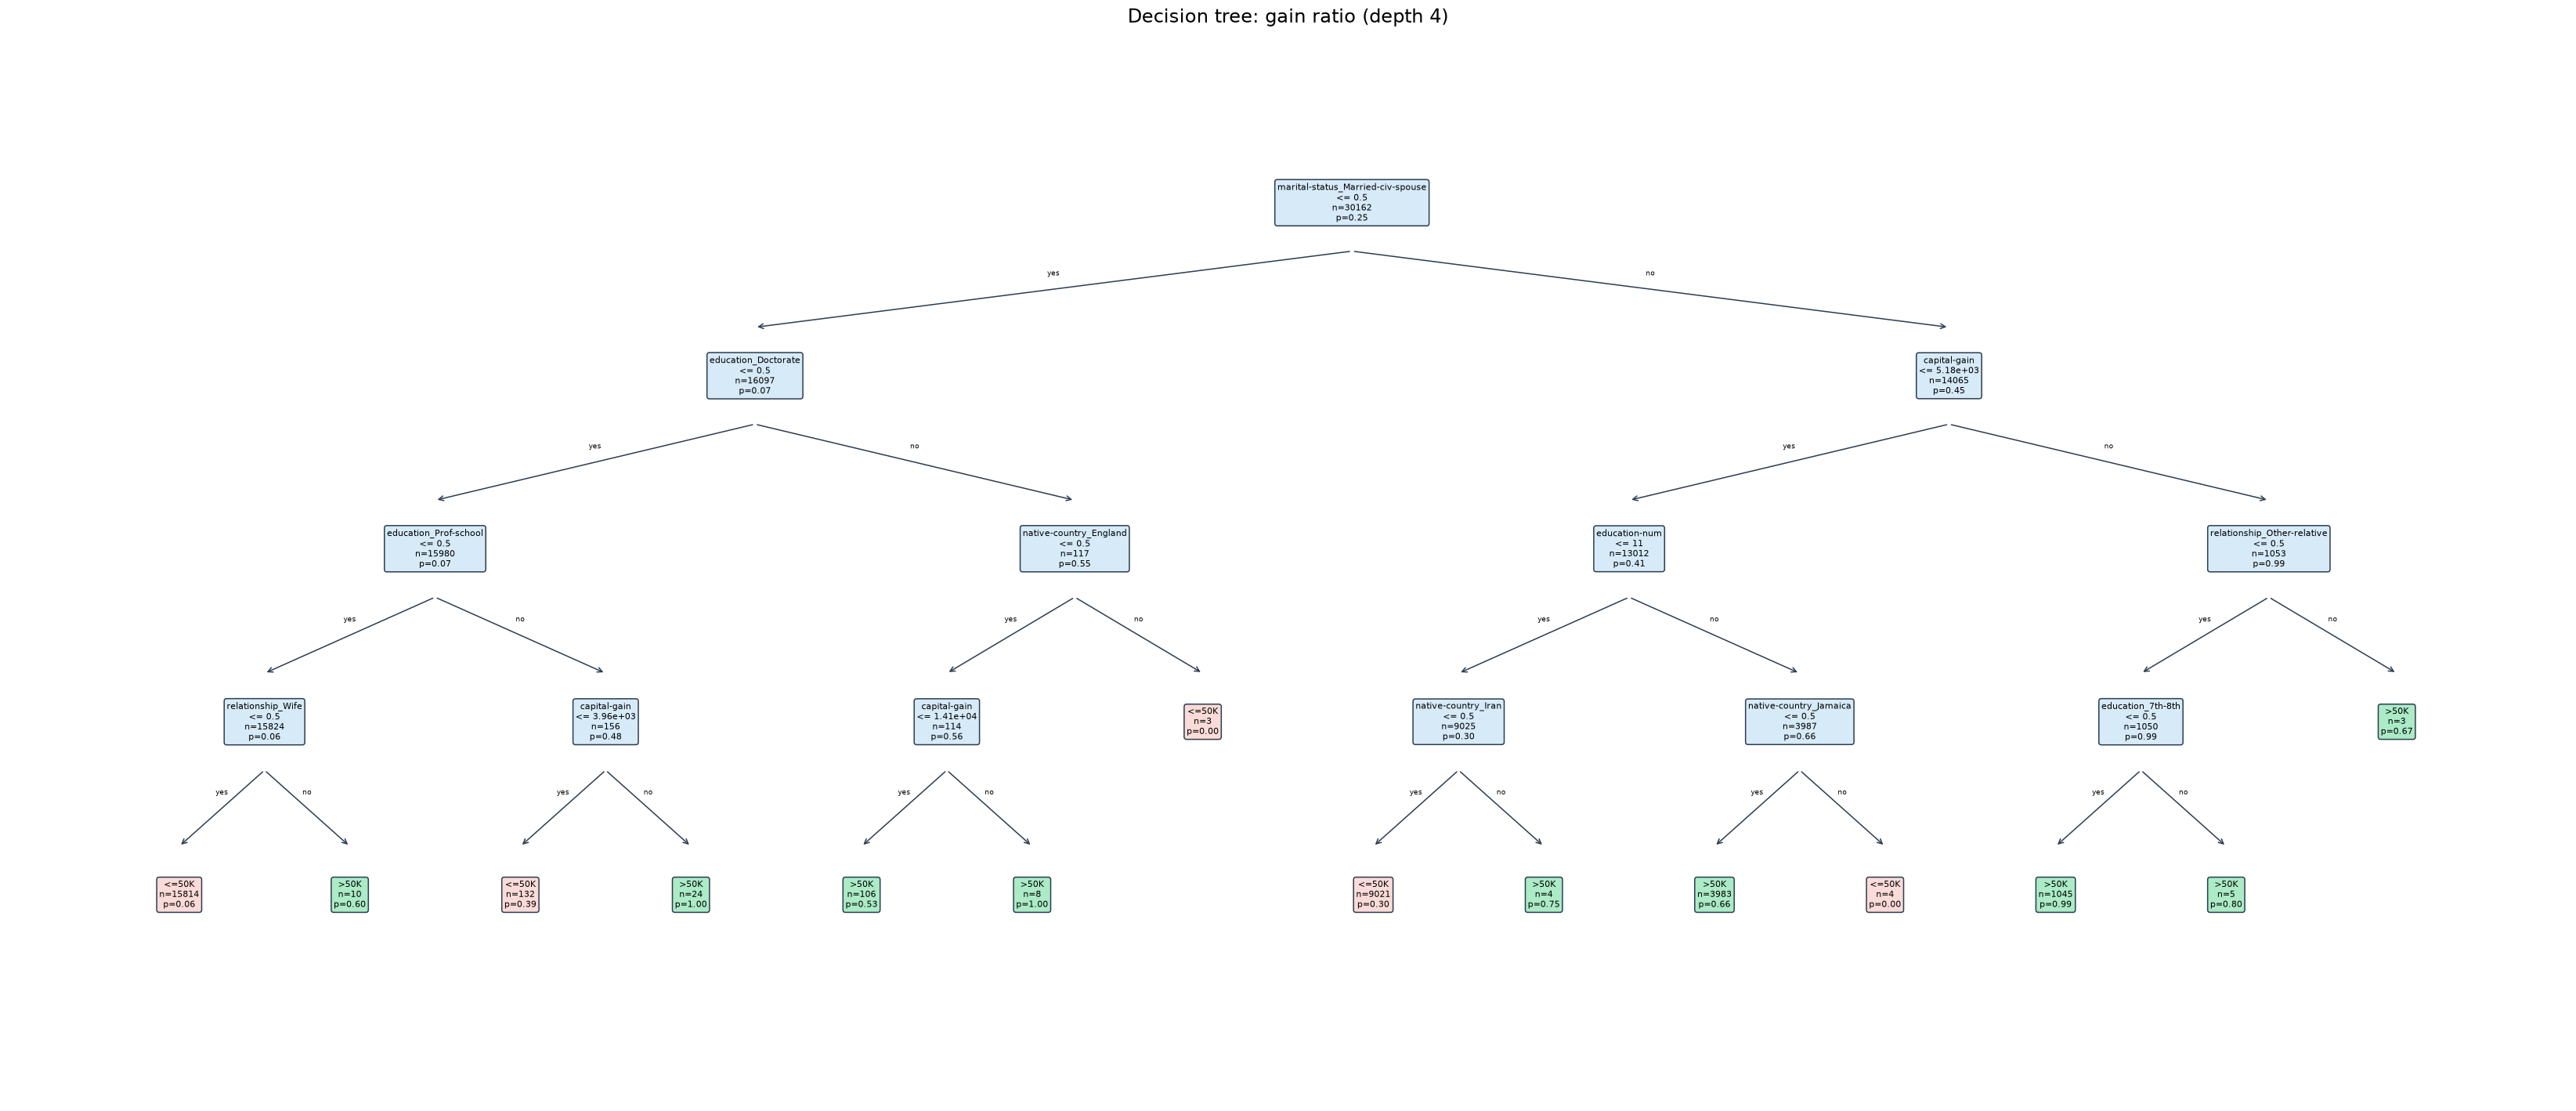

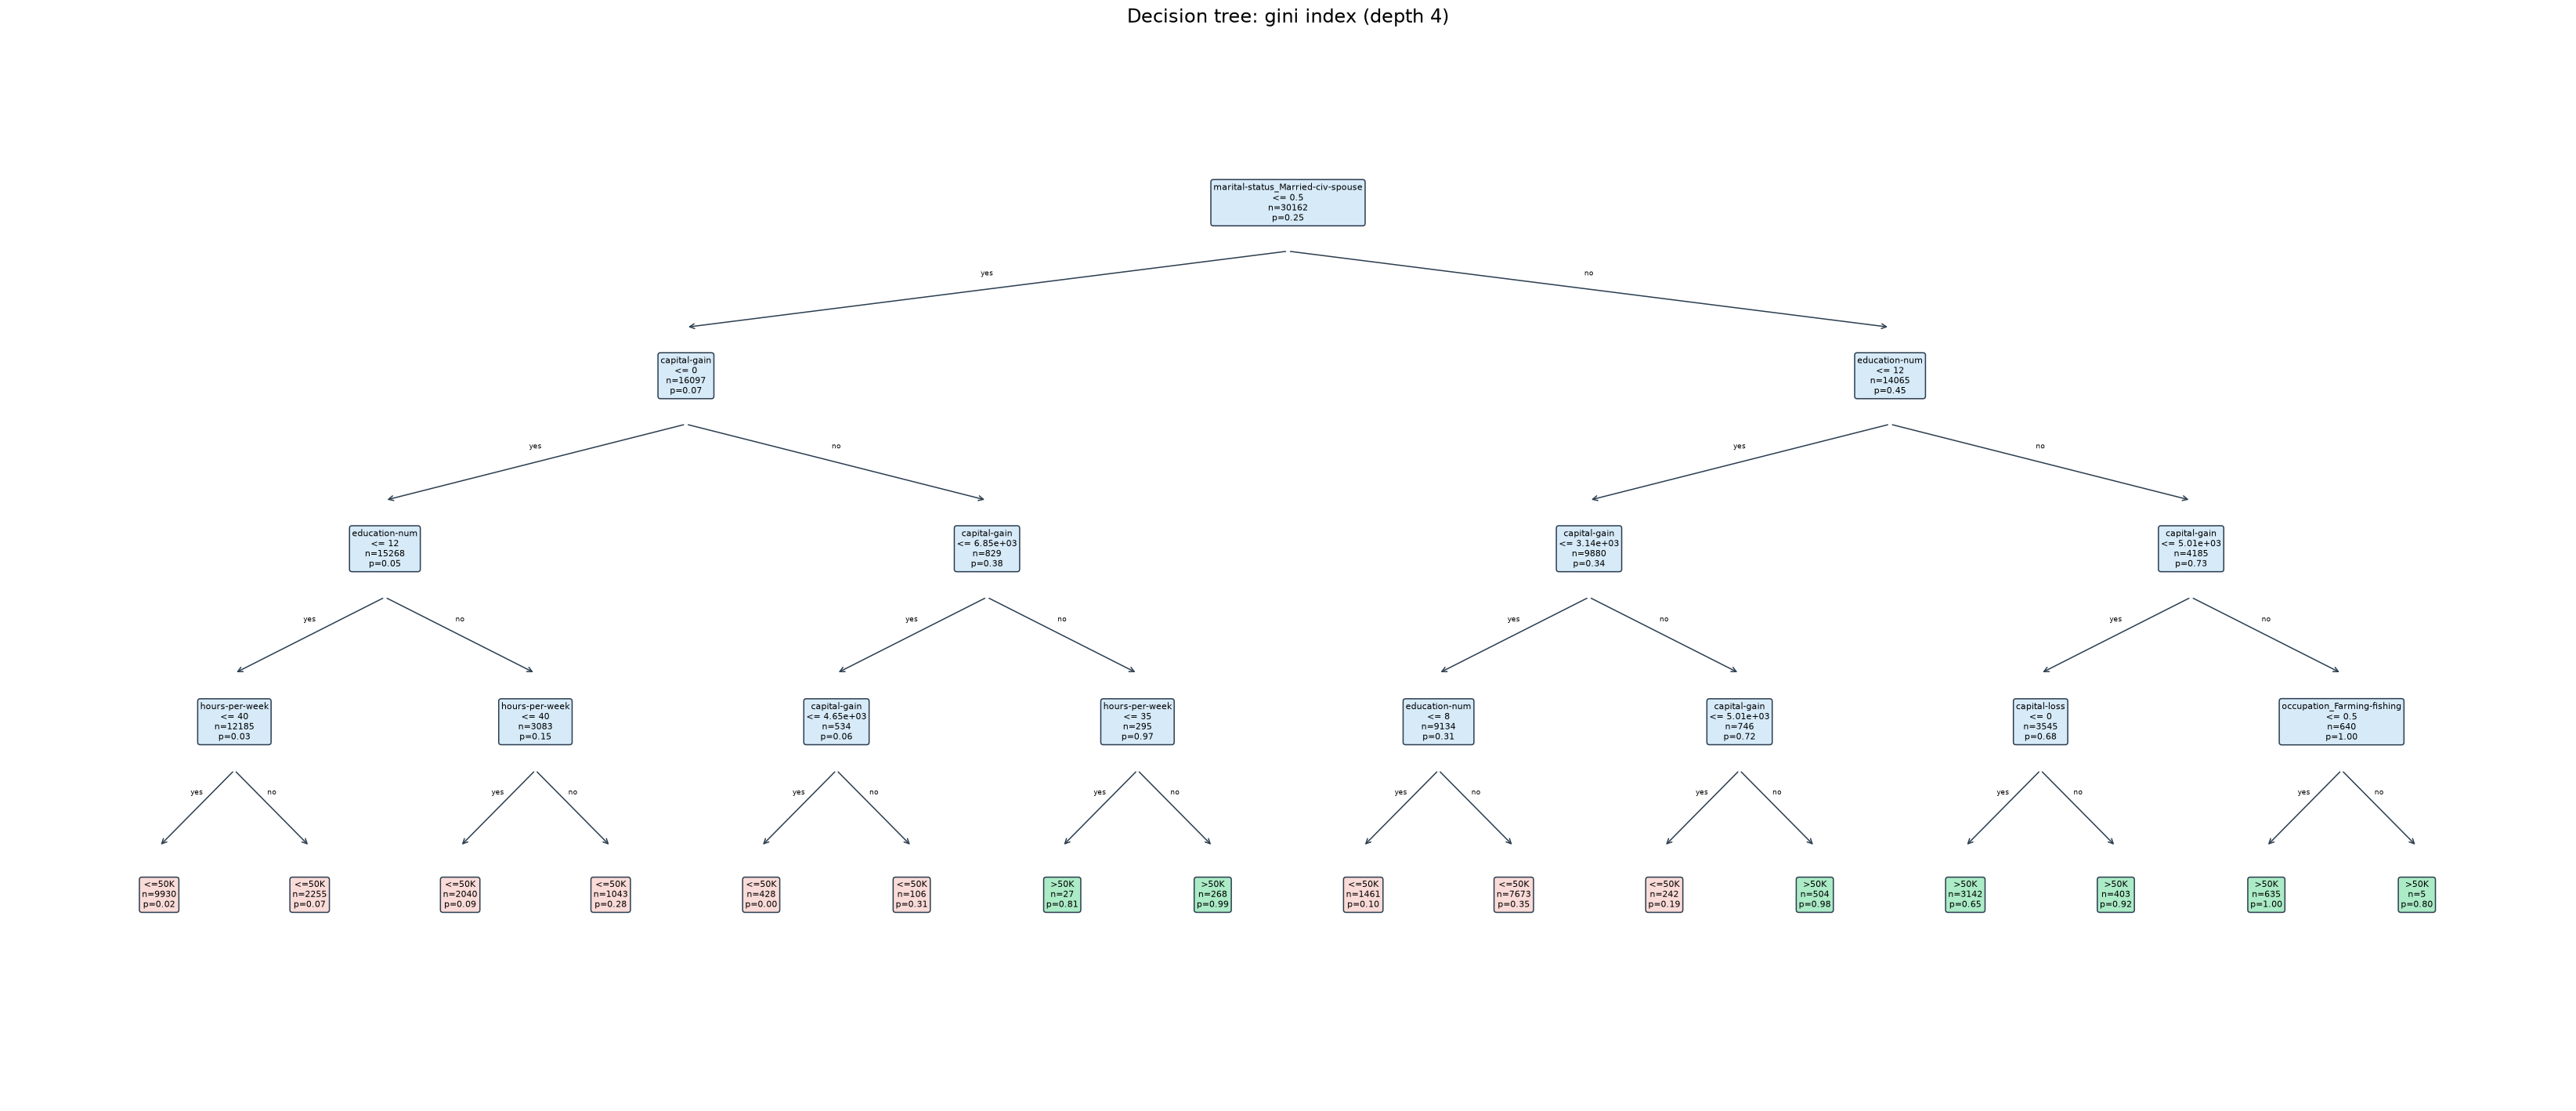

In [6]:
SHALLOW_DEPTH = 4
shallow_trees = {}
for criterion in CRITERIA:
    shallow_trees[criterion] = DecisionTree(criterion=criterion,
                                            max_depth=SHALLOW_DEPTH).fit(X_full, y_full, feature_names)
    nodes, depth = shallow_trees[criterion].count_nodes()
    print("%-16s shallow nodes=%2d depth=%d" % (criterion, nodes, depth))


def export_text(tree, names, max_depth=None):
    lines = []

    def visit(node, depth):
        pad = "  " * depth
        if node.feature is None or (max_depth is not None and depth >= max_depth):
            label = ">50K" if node.proba >= 0.5 else "<=50K"
            lines.append("%s=> %s [n=%d, p(>50K)=%.3f]" % (pad, label, node.n, node.proba))
            return
        lines.append("%s[%s <= %.3g] (gain=%.4f) [n=%d, p(>50K)=%.3f]"
                     % (pad, names[node.feature], node.threshold, node.gain, node.n, node.proba))
        visit(node.left, depth + 1)
        visit(node.right, depth + 1)

    visit(tree.root, 0)
    return "\n".join(lines)


print()
print("Дерево information_gain (глубина 4), текстовый вид:")
print(export_text(shallow_trees["information_gain"], feature_names))


def plot_tree(tree, names, path, title):
    xs = {}
    counter = [0]
    max_d = [0]

    def assign(node, depth):
        max_d[0] = max(max_d[0], depth)
        if node.feature is None:
            xs[id(node)] = float(counter[0])
            counter[0] += 1
        else:
            assign(node.left, depth + 1)
            assign(node.right, depth + 1)
            xs[id(node)] = (xs[id(node.left)] + xs[id(node.right)]) / 2.0

    assign(tree.root, 0)
    fig, ax = plt.subplots(figsize=(30, 13))
    ax.set_title(title, fontsize=16)
    ax.set_axis_off()

    def draw(node, depth):
        x = xs[id(node)]
        y = -depth
        if node.feature is None:
            label = ">50K" if node.proba >= 0.5 else "<=50K"
            text = "%s\nn=%d\np=%.2f" % (label, node.n, node.proba)
            color = "#ABEBC6" if node.proba >= 0.5 else "#FADBD8"
        else:
            text = "%s\n<= %.3g\nn=%d\np=%.2f" % (names[node.feature],
                                                    node.threshold, node.n, node.proba)
            color = "#D6EAF8"
        ax.annotate(text, xy=(x, y), xycoords="data", ha="center", va="center", fontsize=7,
                    bbox=dict(boxstyle="round,pad=0.3", fc=color, ec="#2C3E50"))
        if node.feature is not None:
            for child, edge in ((node.left, "yes"), (node.right, "no")):
                cx, cy = xs[id(child)], -(depth + 1)
                ax.annotate("", xy=(cx, cy + 0.28), xytext=(x, y - 0.28),
                            arrowprops=dict(arrowstyle="->", color="#2C3E50"))
                ax.text((x + cx) / 2.0, (y + cy) / 2.0 + 0.08, edge, fontsize=6, ha="center")
            draw(node.left, depth + 1)
            draw(node.right, depth + 1)

    draw(tree.root, 0)
    ax.set_xlim(-1, counter[0])
    ax.set_ylim(-max_d[0] - 1.2, 1.0)
    fig.tight_layout()
    fig.savefig(path, dpi=110, bbox_inches="tight")
    plt.close(fig)
    print("Сохранено:", path)


plot_tree(shallow_trees["information_gain"], feature_names,
          "tree_information_gain.png", "Decision tree: information gain (depth 4)")
plot_tree(shallow_trees["gain_ratio"], feature_names,
          "tree_gain_ratio.png", "Decision tree: gain ratio (depth 4)")
plot_tree(shallow_trees["gini"], feature_names,
          "tree_gini.png", "Decision tree: gini index (depth 4)")

## 6. Эксперимент Б: варьирование доли обучающей выборки

Здесь критерий один на всех — **Information gain** (`max_depth=8`). Очищенный набор `adult.data.txt` делим на обучающую и тестовую части в соотношениях 60:40, 70:30, 80:20 и 90:10. Разбиение стратифицированное, доля класса `>50K` в обеих частях сохраняется. Зерно генератора зафиксировано (`RANDOM_STATE=42`), так что эксперимент повторяется один в один. На отложенной части считаем accuracy, precision, recall и F-меру.


In [7]:
def stratified_split(y, train_size, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    mask = np.zeros(len(y), dtype=bool)
    for cls in (0, 1):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        mask[idx[:int(len(idx) * train_size)]] = True
    return mask


rows_b = []
for share in (0.6, 0.7, 0.8, 0.9):
    mask = stratified_split(y_full, share)
    t0 = time.time()
    tree = DecisionTree(criterion="information_gain", max_depth=DEEP_DEPTH).fit(
        X_full[mask], y_full[mask], feature_names)
    elapsed = time.time() - t0
    m = classification_metrics(y_full[~mask], tree.predict(X_full[~mask]))
    rows_b.append({"train_share": share, "train_n": int(mask.sum()), "test_n": int((~mask).sum()),
                   "accuracy": round(m["accuracy"], 4), "precision": round(m["precision"], 4),
                   "recall": round(m["recall"], 4), "f1": round(m["f1"], 4)})
    print("train=%.0f%% (n=%d) time=%4.1f c  acc=%.4f prec=%.4f rec=%.4f f1=%.4f"
          % (100 * share, mask.sum(), elapsed, m["accuracy"], m["precision"],
             m["recall"], m["f1"]))
results_b = pd.DataFrame(rows_b)
print()
print(results_b.to_string(index=False))

train=60% (n=18096) time= 2.8 c  acc=0.8378 prec=0.7675 rec=0.5000 f1=0.6055
train=70% (n=21112) time= 3.2 c  acc=0.8433 prec=0.7576 rec=0.5451 f1=0.6340
train=80% (n=24129) time= 3.6 c  acc=0.8419 prec=0.7468 rec=0.5519 f1=0.6348
train=90% (n=27145) time= 4.0 c  acc=0.8439 prec=0.7574 rec=0.5486 f1=0.6363

 train_share  train_n  test_n  accuracy  precision  recall     f1
         0.6    18096   12066    0.8378     0.7675  0.5000 0.6055
         0.7    21112    9050    0.8433     0.7576  0.5451 0.6340
         0.8    24129    6033    0.8419     0.7468  0.5519 0.6348
         0.9    27145    3017    0.8439     0.7574  0.5486 0.6363


## 7. Визуализация: метрики в зависимости от доли обучающей выборки

Строим четыре кривые (accuracy, precision, recall, F-мера) от доли обучающей выборки. Рисунок сохраняем в `metrics_vs_split.png`.

Сохранено: metrics_vs_split.png
Прирост 60% -> 90%: acc +0.0061, prec -0.0101, rec +0.0486, f1 +0.0308


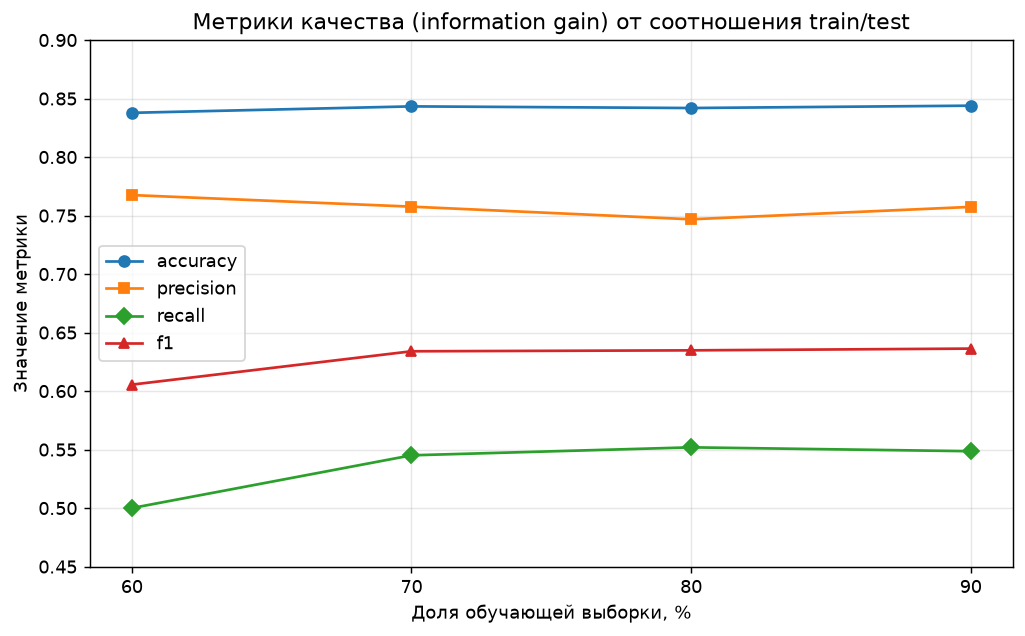

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for col, style in (("accuracy", "o-"), ("precision", "s-"), ("recall", "D-"), ("f1", "^-")):
    ax.plot(results_b["train_share"] * 100, results_b[col], style, label=col)
ax.set_xlabel("Доля обучающей выборки, %")
ax.set_ylabel("Значение метрики")
ax.set_title("Метрики качества (information gain) от соотношения train/test")
ax.set_xticks([60, 70, 80, 90])
ax.set_ylim(0.45, 0.9)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("metrics_vs_split.png", dpi=130, bbox_inches="tight")
plt.close(fig)
print("Сохранено: metrics_vs_split.png")
print("Прирост 60%% -> 90%%: acc %+.4f, prec %+.4f, rec %+.4f, f1 %+.4f"
      % tuple(results_b.iloc[-1][["accuracy", "precision", "recall", "f1"]].values
              - results_b.iloc[0][["accuracy", "precision", "recall", "f1"]].values))

## 8. Выводы

**Сравнение критериев (обучение на 100% `adult.data.txt`, тест `adult.test.txt`):**

- Information gain и Gini index показали почти одинаковое качество: accuracy 0.8501 и 0.8502, F-мера 0.6857 и 0.6825, деревья из 231 и 227 узлов. Это сходится с литературой: в `adult.names.txt` для C4.5 указано 84.46%, а у нас при глубине 8 вышло около 85.0%;
- Gain ratio построил дерево заметно компактнее, всего 89 узлов, зато accuracy просела до 0.8376 (−1.2 п.п.), а F-мера — до 0.6166. Всё дело в нормировке на Split info. Она занижает оценку сбалансированных информативных разбиений, поэтому дерево останавливается раньше времени;
- корневое разбиение у всех трёх критериев одинаковое: `marital-status = Married-civ-spouse`. Среди не состоящих в браке доход `>50K` только у 6.9%, а среди состоящих — у 45.5%. Прирост информации 0.1529 — самый большой среди всех признаков. Под корнем идут разбиения по `capital-gain`, `education-num` и возрасту, это видно на рисунках деревьев глубины 4;
- одно дерево обучается 2–4 секунды на 30 тыс. объектов и 104 признаках.

**Влияние доли обучающей выборки (критерий Information gain, 60% → 90%):**

- accuracy поднимается с 0.8378 до 0.8439 и дальше почти не меняется уже после 70%. Мажоритарный класс дерево схватывает быстро;
- recall растёт сильнее всех: с 0.5000 до 0.5486 (+0.0486), потому что лишние данные помогают находить как раз редкий класс `>50K`;
- precision почти стоит на месте, 0.7468–0.7675: чем больше данных, тем больше кандидатов в `>50K` находит дерево, и часть из них оказывается ложной;
- F-мера растёт с 0.6055 до 0.6363 без провалов, а самый большой шаг — между 60% и 70% (+0.0285), дальше прирост затухает.

**Общий смысл:** accuracy 0.84–0.85 смотрится высокой, но это во многом эффект дисбаланса, ведь 75% объектов — это `<=50K`. У меньшего класса числа скромнее: precision ~0.75, recall ~0.55–0.67. Для задачи «найти людей с доходом выше $50K» смотреть надо на recall и F-меру. Оба растут вместе с обучающей выборкой, и оба выше у Information gain и Gini index, чем у Gain ratio.

Файлы результатов в `lab3/`: `tree_information_gain.png`, `tree_gain_ratio.png`, `tree_gini.png`, `metrics_vs_split.png`.
